In [1]:
# Cervical Cancer Risk Analysis

# Cervical Cancer Risk Factor Analysis

## Project Overview
Cervical cancer is one of the most common cancers affecting women worldwide. Early detection and understanding of risk factors can significantly improve prevention and treatment outcomes.

This project analyzes a cervical cancer risk factor dataset to identify relationships between demographic, behavioral, and medical factors and cervical cancer diagnosis.

## Objectives
The main objectives of this project are:

- Clean and preprocess the dataset by handling missing values and incorrect data types
- Perform exploratory data analysis to understand the distribution of key variables
- Identify potential risk factors associated with cervical cancer
- Visualize relationships between variables such as age, smoking, STD history, and cancer diagnosis
- Generate insights that can help in understanding cervical cancer risk patterns

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Description
The dataset contains medical and behavioral information for patients including:

- Age
- Number of sexual partners
- First sexual intercourse age
- Number of pregnancies
- Smoking habits
- STD history
- HPV infection
- Cervical cancer diagnostic test results

The target variable used for analysis is **Biopsy**, which indicates whether cervical cancer was detected.

In [2]:
## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np

In [4]:
## 2. Load Dataset

In [5]:
import os
os.listdir()

['.ipynb_checkpoints',
 'cervical_cancer_cleaned.csv',
 'Cervical_cancer_project.ipynb',
 'Pyhton_Practice.ipynb']

In [6]:
df = pd.read_csv("../kag_risk_factors_cervical_cancer.csv")

In [7]:
## 3. Data Cleaning

In [8]:
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [9]:
df.shape

(858, 36)

In [10]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

## Data Cleaning and Preprocessing
The dataset contains missing values represented by '?' symbols and several columns with high missingness. The cleaning process includes replacing placeholder values, removing columns with excessive missing data, converting data types, and standardizing column names for analysis.

In [12]:
df = df.replace("?", np.nan)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           832 non-null    object
 2   First sexual intercourse            851 non-null    object
 3   Num of pregnancies                  802 non-null    object
 4   Smokes                              845 non-null    object
 5   Smokes (years)                      845 non-null    object
 6   Smokes (packs/year)                 845 non-null    object
 7   Hormonal Contraceptives             750 non-null    object
 8   Hormonal Contraceptives (years)     750 non-null    object
 9   IUD                                 741 non-null    object
 10  IUD (years)                         741 non-null    object
 11  STDs                                753 non-null    object

In [14]:
df.isnull().sum().sort_values(ascending = False)

STDs: Time since last diagnosis       787
STDs: Time since first diagnosis      787
IUD                                   117
IUD (years)                           117
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
STDs:pelvic inflammatory disease      105
STDs:vulvo-perineal condylomatosis    105
STDs:HPV                              105
STDs:Hepatitis B                      105
STDs:HIV                              105
STDs:AIDS                             105
STDs:molluscum contagiosum            105
STDs:genital herpes                   105
STDs:syphilis                         105
STDs:vaginal condylomatosis           105
STDs:cervical condylomatosis          105
STDs:condylomatosis                   105
STDs (number)                         105
STDs                                  105
Num of pregnancies                     56
Number of sexual partners              26
Smokes (packs/year)                    13
Smokes (years)                    

In [15]:
df= df.drop(columns=['STDs: Time since last diagnosis','STDs: Time since first diagnosis'])

In [16]:
df = df.apply(pd.to_numeric)

In [17]:
df= df.fillna(0)

In [18]:
df.duplicated().sum()

np.int64(34)

In [19]:
df.columns = df.columns.str.replace(" ","_")
df.columns = df.columns.str.replace("(","")
df.columns = df.columns.str.replace(")", "")
df.columns = df.columns.str.replace(":", "")
df.columns = df.columns.str.lower()

In [20]:
df.columns

Index(['age', 'number_of_sexual_partners', 'first_sexual_intercourse',
       'num_of_pregnancies', 'smokes', 'smokes_years', 'smokes_packs/year',
       'hormonal_contraceptives', 'hormonal_contraceptives_years', 'iud',
       'iud_years', 'stds', 'stds_number', 'stdscondylomatosis',
       'stdscervical_condylomatosis', 'stdsvaginal_condylomatosis',
       'stdsvulvo-perineal_condylomatosis', 'stdssyphilis',
       'stdspelvic_inflammatory_disease', 'stdsgenital_herpes',
       'stdsmolluscum_contagiosum', 'stdsaids', 'stdshiv', 'stdshepatitis_b',
       'stdshpv', 'stds_number_of_diagnosis', 'dxcancer', 'dxcin', 'dxhpv',
       'dx', 'hinselmann', 'schiller', 'citology', 'biopsy'],
      dtype='object')

In [21]:
## 4 Import Visualization Libraries

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution of variables and identify potential relationships between risk factors and cervical cancer diagnosis.

In [23]:
## Exploratory Data Analysis

The correlation heatmap helps identify relationships between different risk factors. HPV infection and STD history show notable correlations with cervical cancer diagnosis.

In [24]:
# (i) Correlation Heatmap of Cervical Cancer Risk Factors.

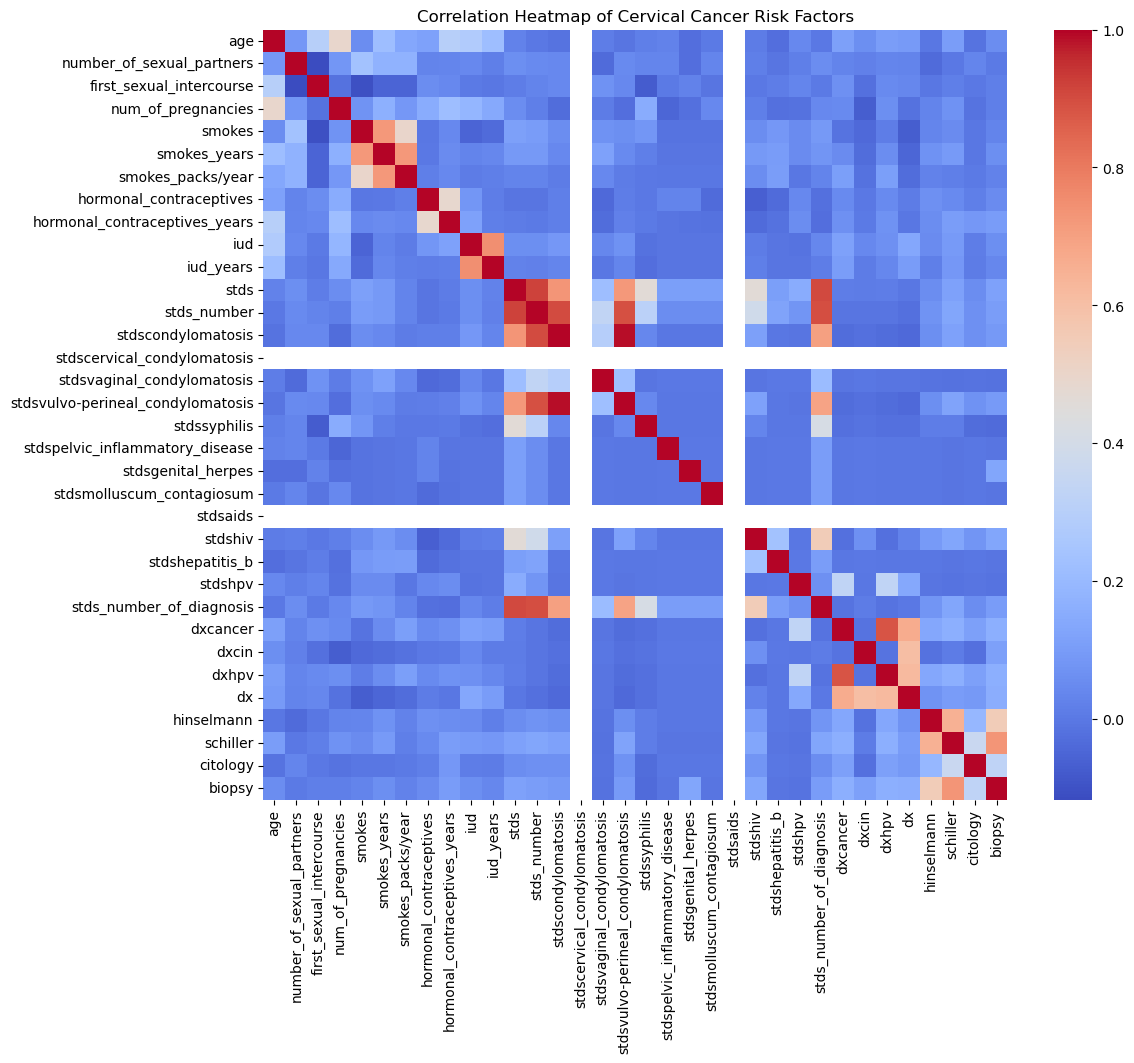

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap= "coolwarm")
plt.title("Correlation Heatmap of Cervical Cancer Risk Factors")
plt.show()

## Age Group Risk Analysis

Age is an important demographic factor that may influence cervical cancer risk. 
This analysis groups patients into age categories to examine whether cervical 
cancer diagnosis rates differ across age groups.

In [26]:
#(ii) Age Distribution

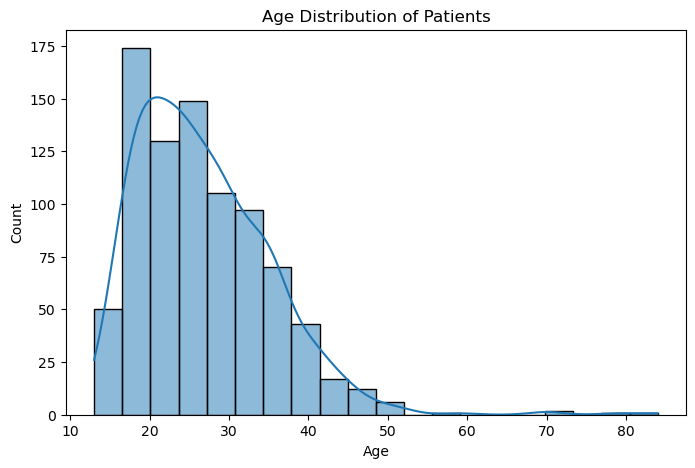

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins= 20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### Insight
Smoking appears to show a relationship with cervical cancer diagnosis. Patients with smoking history demonstrate slightly higher cancer diagnosis rates compared to non-smokers.

In [28]:
#(iii) Smoking Vs Cervical Cancer

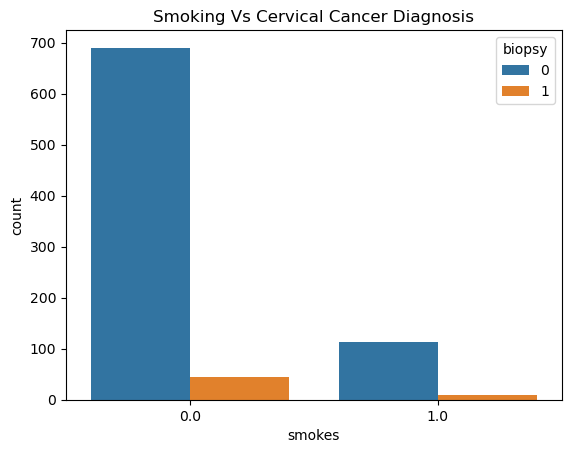

In [29]:
sns.countplot(x='smokes', hue='biopsy' , data= df)
plt.title("Smoking Vs Cervical Cancer Diagnosis")
plt.show()

Patients diagnosed with cervical cancer tend to have slightly higher pregnancy counts compared to those without cancer diagnosis.

In [30]:
#(iv) Number of pregnancy analysis.

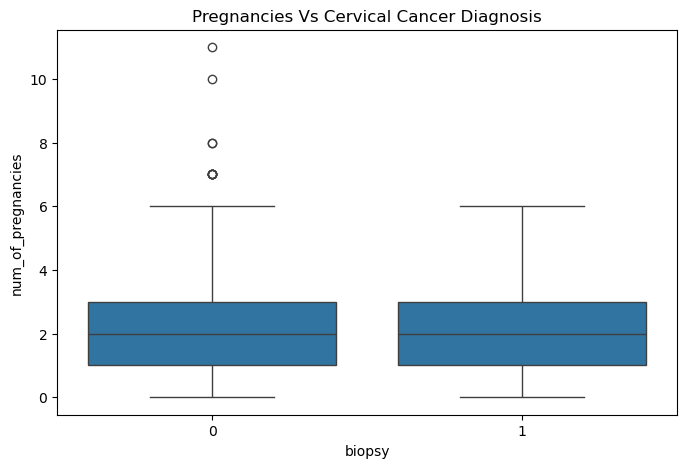

In [31]:
plt.figure(figsize = (8,5))
sns.boxplot(x= 'biopsy', y='num_of_pregnancies', data = df)
plt.title("Pregnancies Vs Cervical Cancer Diagnosis")
plt.show()

HPV infection demonstrates a strong association with cervical cancer diagnosis. This aligns with medical research which identifies HPV as a major risk factor for cervical cancer.

In [32]:
#(v) HPV Vs Cervical Cancer.

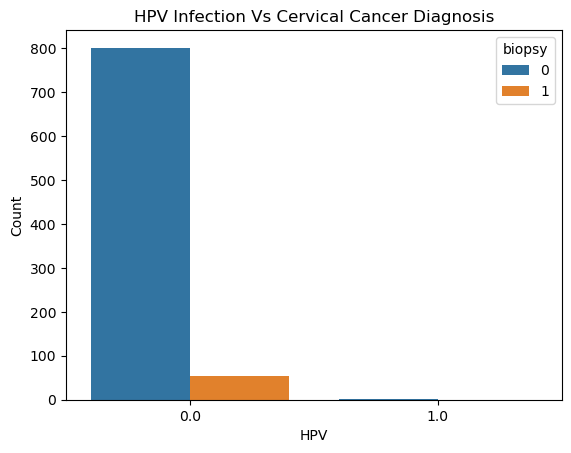

In [33]:
sns.countplot(data= df,x= 'stdshpv', hue='biopsy')
plt.title("HPV Infection Vs Cervical Cancer Diagnosis")
plt.xlabel("HPV")
plt.ylabel("Count")
plt.show()

## Key Insights

- HPV infection shows a strong relationship with cervical cancer diagnosis.
- Smoking history appears to increase the probability of cervical cancer.
- Patients with STD history demonstrate higher cancer diagnosis rates.
- Age distribution indicates that cervical cancer cases tend to occur more frequently in older age groups.
- Several lifestyle and medical factors appear to influence cervical cancer risk.

## Conclusion

This analysis explored various demographic, behavioral, and medical factors associated with cervical cancer diagnosis. The dataset was first cleaned by handling missing values, removing columns with excessive missing data, and standardizing column names. Exploratory Data Analysis was then performed to identify patterns and relationships between potential risk factors and cervical cancer outcomes.

The analysis revealed that HPV infection, STD history, and certain diagnostic tests show strong relationships with cervical cancer diagnosis. Lifestyle and behavioral factors such as smoking and reproductive history also appear to contribute to variations in cancer risk. Additionally, age distribution analysis suggests that cervical cancer cases tend to occur more frequently among older patients.

Overall, the findings align with established medical research indicating that HPV infection is a major risk factor for cervical cancer and that behavioral and medical history variables can help in understanding patient risk profiles.

## Recommendations

Based on the analysis of cervical cancer risk factors, the following recommendations can be considered:

- Increase awareness and screening programs focused on HPV detection and prevention.
- Promote early cervical cancer screening for women in higher-risk age groups.
- Encourage preventive healthcare measures such as HPV vaccination and regular medical checkups.
- Monitor patients with STD history more closely as they may have elevated cervical cancer risk.
- Further analysis using predictive modeling techniques could help identify high-risk patients and support early intervention strategies.

In [34]:
df.to_csv("cervical_cancer_cleaned.csv",index=False)